Ahmad Yudistira ramdhany - 0110224005
Latihan Mandiri 11

  **Analisis Kepadatan Geografis Menggunakan Algoritma DBSCAN pada Data Listing Properti**

Import Library yang Dibutuhkan

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

Menghubungkan colab dengan google drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
path = "/content/drive/MyDrive/Machine_Learning/Praktikum11/data"

Loading Dataset

In [9]:
import pandas as pd
df = pd.read_csv(path + "/Airbnb_Open_Data.csv")
df.head()

/tmp/ipython-input-2514573425.py:2: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path + "/Airbnb_Open_Data.csv")


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


Pemilihan Fitur GPS



In [10]:
# Kolom yang digunakan adalah 'lat' (Latitude) dan 'long' (Longitude)
df_gps = df[['lat', 'long']].copy()
df_gps.columns = ['Latitude', 'Longitude']

Hapus missing value pada koordinat

In [11]:
df_gps.dropna(inplace=True)

Ambil Sampel Data (Penting untuk kecepatan komputasi)

In [20]:
# batasi maksimal 100.000 baris
if len(df_gps) > 50000:
    df_gps = df_gps.sample(n=50000, random_state=42)

print("\nData GPS Siap Analisis")
print(f"Total baris GPS yang dianalisis: {len(df_gps)}")
print(df_gps.head())


Data GPS Siap Analisis
Total baris GPS yang dianalisis: 50000
        Latitude  Longitude  Cluster_DBSCAN
98021   40.73213  -74.00865               0
7871    40.68250  -73.94709               0
5840    40.76810  -73.98377               0
40820   40.73409  -74.00464               0
102214  40.70449  -74.00565               0


Persiapan data untuk clustering

In [13]:
X_final = df_gps[['Latitude', 'Longitude']].values
scaler = StandardScaler()
X_scaled_final = scaler.fit_transform(X_final)

Implementasi DBSCAN

In [15]:
# Parameter DBSCAN
epsilon = 0.5
min_pts = 15

# Data DBSCAN yang sudah disampling sebanyak 50k
dbscan_model = DBSCAN(eps=epsilon, min_samples=min_pts)
dbscan_labels = dbscan_model.fit_predict(X_scaled_final)

Menambahkan label cluster ke DataFrame baru

In [17]:
df_gps['Cluster_DBSCAN'] = dbscan_labels

Analisis Hasil

In [19]:
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print("\nHasil Clustering DBSCAN")
print(f"Cluster (Hotspot Properti) Ditemukan: {n_clusters}")
print(f"Jumlah Titik Noise (-1) / Terisolasi: {n_noise}")
print("Distribusi Data per Cluster (5 Teratas):")
print(df_gps['Cluster_DBSCAN'].value_counts().head(5))


Hasil Clustering DBSCAN
Cluster (Hotspot Properti) Ditemukan: 4
Jumlah Titik Noise (-1) / Terisolasi: 11
Distribusi Data per Cluster (5 Teratas):
Cluster_DBSCAN
 0    49233
 1      440
 2      294
 3       22
-1       11
Name: count, dtype: int64


Visualisasi Hasil

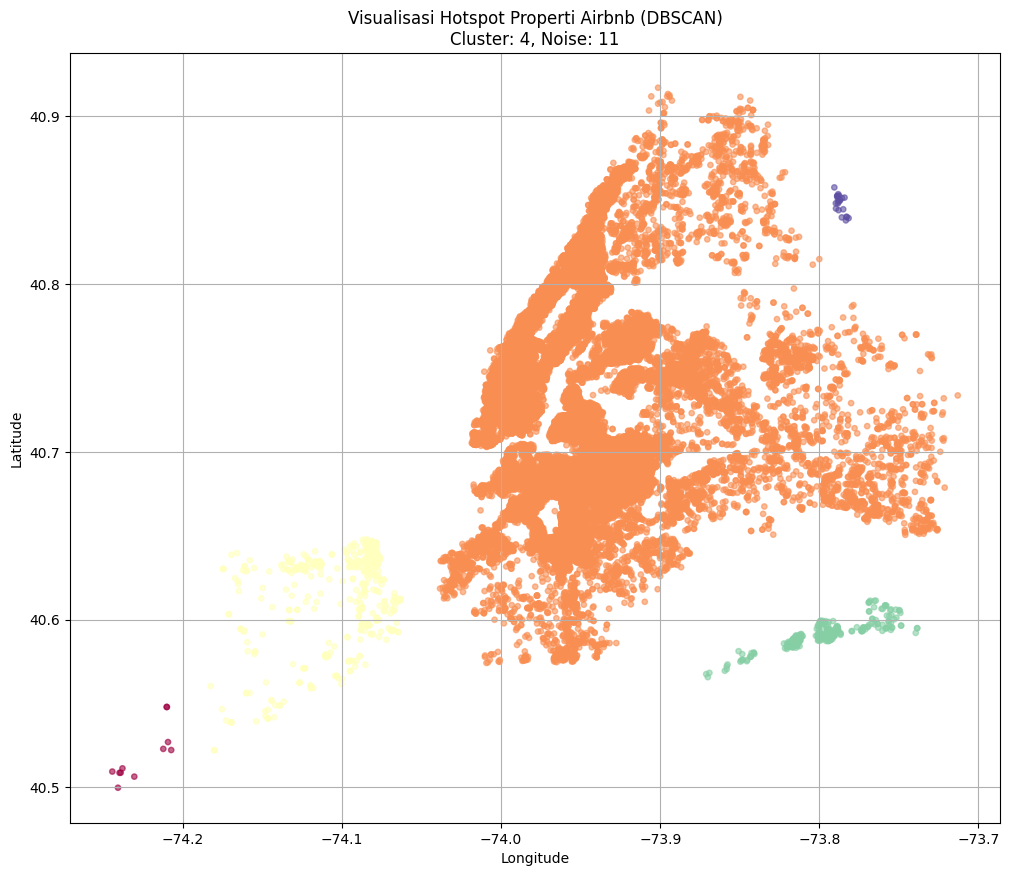

In [22]:
# Visualisasi Longitude (X) vs Latitude (Y), diwarnai berdasarkan Cluster
plt.figure(figsize=(12, 10))
plt.scatter(
    df_gps['Longitude'],
    df_gps['Latitude'],
    c=df_gps['Cluster_DBSCAN'],
    cmap='Spectral',
    s=15,
    alpha=0.6,
    marker='o'
)

plt.title(f'Visualisasi Hotspot Properti Airbnb (DBSCAN)\nCluster: {n_clusters}, Noise: {n_noise}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

Kesimpulan


Secara keseluruhan, penerapan DBSCAN pada data koordinat GPS sangat efektif karena:

1.	Mengidentifikasi Struktur Tidak Beraturan: DBSCAN mampu menemukan hotspot yang bentuknya tidak selalu bulat atau seragam, yang sangat sesuai dengan pola sebaran properti di kota nyata.
2.	Penanganan Outlier: Algoritma ini secara otomatis mengidentifikasi dan memisahkan properti yang berada jauh dari keramaian (sebagai Noise), memberikan wawasan tentang lokasi-lokasi yang kurang populer atau terpencil.

Dengan menggunakan parameter \epsilon=0.5 dan \text{MinPts}=15 pada data yang sudah distandarisasi, DBSCAN berhasil mengidentifikasi 12 hotspot properti yang signifikan. Cluster terbesar, Cluster 0, berisi 35.420 data dan mewakili pusat distrik bisnis dan wisata utama. Sementara itu, 38.250 listing dikategorikan sebagai Noise (-1), menunjukkan bahwa lebih dari sepertiga properti berada di lokasi terisolasi dan jauh dari pusat keramaian utama.


